In [1]:
import os
import numpy as np
import pandas as pd

from src import Dataloader,SIR_PF

import matplotlib.pyplot as plt
from  scipy.optimize import curve_fit

### Visualize Nick's data

In [2]:
dataloader = Dataloader('data_NE', 'none')
dataloader.data_folder

{1: 'DIC_Specimen01.csv',
 2: 'DIC_Specimen02.csv',
 5: 'DIC_Specimen05.csv',
 6: 'DIC_Specimen06.csv',
 7: 'DIC_Specimen07.csv',
 8: 'DIC_Specimen08.csv',
 9: 'DIC_Specimen09.csv',
 10: 'DIC_Specimen10.csv',
 11: 'DIC_Specimen11.csv',
 12: 'DIC_Specimen12.csv'}

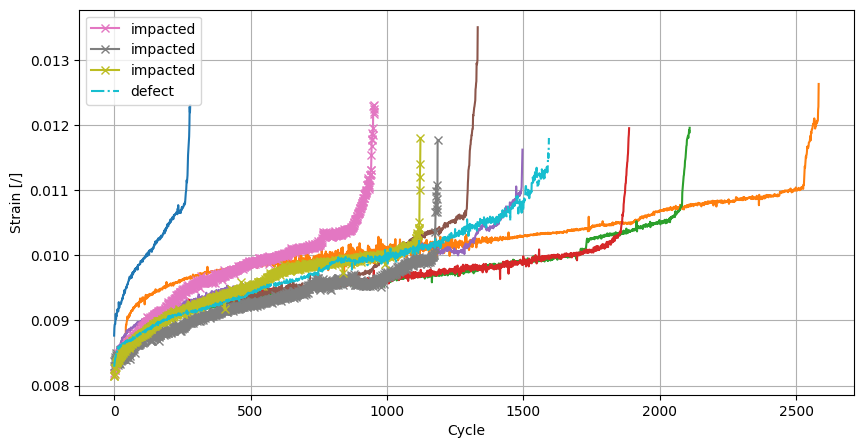

In [3]:
# f = dic_data[0]
plt.figure(figsize=(10,5))
# plt.title('Axial strain DIC data')
plt.xlabel('Cycle')
plt.ylabel('Strain [/]')
plt.grid()


for f in dataloader.data_folder.keys():    
    if f in [9,11,10]:
        plt.plot(dataloader.load_id(f),'-x', label = 'impacted')
    elif f == 12:
        plt.plot(dataloader.load_id(f),'-.', label = 'defect')
    else:
        plt.plot(dataloader.load_id(f))
plt.legend()
plt.show()



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


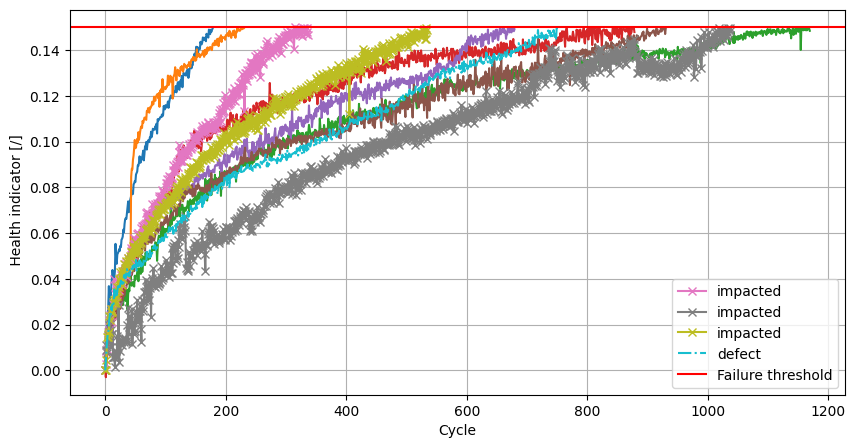

In [7]:
dataloader.thresh = 0.15
dataloader.hi = 'stiffness_red'

plt.figure(figsize=(10,5))
# plt.title('Axial strain change DIC data')
plt.xlabel('Cycle')
plt.ylabel(' Health indicator [/]')
plt.grid()

for f in dataloader.data_folder.keys():    
    if f in [9,11,10]:
        plt.plot(dataloader.load_id(f),'-x', label = 'impacted')
    elif f == 12:
        plt.plot(dataloader.load_id(f),'-.', label = 'defect')
    else:
        plt.plot(dataloader.load_id(f))

plt.axhline(dataloader.thresh, color = 'r', label = 'Failure threshold')

plt.legend()
plt.savefig('HI_data.eps')
plt.show()

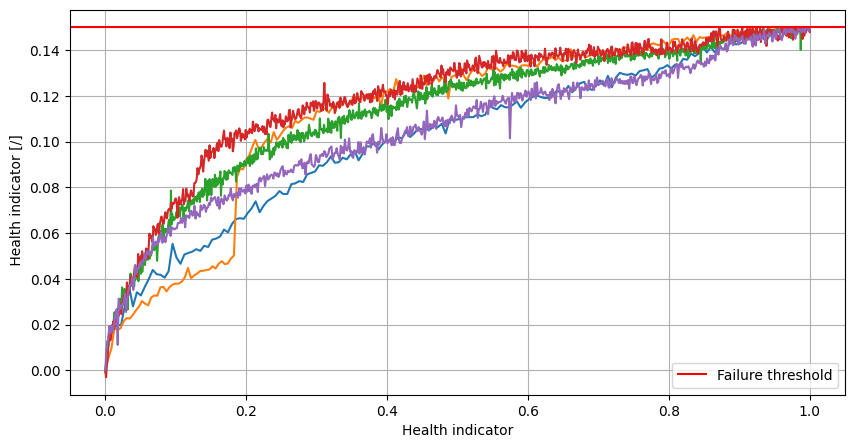

In [8]:
plt.figure(figsize=(10,5))
# plt.title('Axial strain change DIC data')
plt.xlabel('Health indicator')
plt.ylabel(' Health indicator [/]')
plt.grid()

# for f in dataloader.data_folder.keys():    
for f in [1,2,5,6, 7]:  
    
    data = dataloader.load_id(f)
    h = np.linspace(0,1, len(data))
    
    
    if f in [9,11,10]:
        plt.plot(h,data,'-x', label = 'impacted')
    elif f == 12:
        plt.plot(h,data,'-.', label = 'defect')
    else:
        plt.plot(h,data)

plt.axhline(dataloader.thresh, color = 'r', label = 'Failure threshold')

plt.legend()
plt.show()

In [ ]:
len(dataloader.ids)

In [ ]:
def poli_fn(hi, a,b,c):
    return a*hi**3+b*hi**2+c*hi


# f_train = [1,2,5,6, 7]
# f_test = [8,9,10,11]

f_train = np.random.choice(list(dataloader.ids), 7, replace=False )
f_test = [i  for i in dataloader.ids if not i in f_train]



data_train = []
hi_train = []
for f in f_train:
    data = dataloader.load_id(f)
    data_train.extend(data)
    hi_train.extend(np.linspace(0,1, len(data)))
    






msg= curve_fit(poli_fn, hi_train,data_train,p0=(1,1,1), full_output=False)
popt = msg[0]
print(msg)
# if msg[-1] is int:
#     print(msg)

h_ = np.linspace(0,1,100)
y_ = poli_fn(h_, *popt)




plt.figure()


# f = 10
for f in f_test:
    data = dataloader.load_id(f)
    h = np.linspace(0,1,len(data))
    plt.scatter(h, data, color = 'b', alpha = 0.2)
for f in f_train:
    data = dataloader.load_id(f)
    h = np.linspace(0,1,len(data))
    plt.scatter(h, data, color = 'g', alpha = 0.2)
    
plt.plot(h_,y_, color = 'r')
plt.grid()
# plt.ylim([0,dataloader.thresh])
plt.show()

In [ ]:
damage_rate = []
for f in dataloader.ids:
    data = dataloader.load_id(f)
    damage_rate.append(1/len(data))
    
plt.figure()
plt.bar(dataloader.ids, damage_rate)
plt.show()

### Implement the PF

In [ ]:
# Load data
dataloader = Dataloader('data_NE', 'percentual', thresh=0.2)

In [ ]:
# Fit obs_eq
def poli_fn(hi, a,b,c):
    return a*hi**3+b*hi**2+c*hi


# f_train = [1,2,5,6, 7]
# f_test = [8,9,10,11]

f_train = np.random.choice(list(dataloader.ids), 7, replace=False )
f_test = [i  for i in dataloader.ids if not i in f_train]



data_train = []
hi_train = []
for f in f_train:
    data = dataloader.load_id(f)
    data_train.extend(data)
    hi_train.extend(np.linspace(0,1, len(data)))
    
msg= curve_fit(poli_fn, hi_train,data_train,p0=(1,1,1), full_output=False)
popt = msg[0]
print(msg)


In [ ]:
# get noise level and damage accumulation rates
errors = []
for f in f_train:
    data = dataloader.load_id(f)
    h = np.linspace(0,1,len(data))
    y = poli_fn(h, *popt)
    errors.extend(data-y)
print('error mean and std:\t', np.mean(errors), np.std(errors))

damage_rate = []
for f in dataloader.ids:
    data = dataloader.load_id(f)
    damage_rate.append(1/len(data))
    
print('damage acc mean and std:\t', np.mean(damage_rate), np.std(damage_rate))



In [ ]:
# Setup the update functinos for the PF 
N_particles = 100
obs_std = np.std(errors)

obs_eq = lambda x: poli_fn(x, *popt)
state_eq = lambda x, p: x+p + np.random.normal(0,1e-3, N_particles)
param_eq = lambda p: p + np.random.normal(0, 1e-3, N_particles)

# Setup the priors
x_0 = np.random.uniform(0, 1e-6, N_particles) # We should be confident that it starts at 0 -> No past uncertainty
p_0 = np.random.normal(np.mean(damage_rate),np.std(damage_rate), N_particles)



In [ ]:
# Instance de PF
particle_filter = SIR_PF(obs_eq, state_eq, param_eq, N_particles, obs_std)
particle_filter.init_state(x_0, p_0)

In [ ]:
data_test = dataloader.load_id(f_test[0])
for y in data_test:
    particle_filter.update(y)
    print(particle_filter.mean())
    